In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import enum
import math
from pandas_ta.volatility import kc 
from datetime import datetime, timezone
from scipy.signal import savgol_filter
    
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL_EMA = 0
    PRICE_ACCION_OVER_EMA = 1
    PRICE_ACCION_UNDER_EMA = 2
    
def calculateEma(df, span):
    
    return df['Close'].ewm(span=span, adjust=False).mean()
        
def calculateBolingerAndKeltnerChannels(kc)->None:
    
    # Bolinger Bands
    df.ta.bbands(append=True, length=20, std=2)
    
    # Initialize Keltner Channel Indictor
    kc=kc(high=df['high_5min'], low=df['low_5min'], close=df["close_5min"], window=20)
    
    #Bolinger Band Upper - Keltner Channel Upper
    df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']
    
def priceActionUptrendInTheDay(zoneWidth = .30)->None:
    
    df['isPriceActionAboveEma25'] = np.where(df.ema25_5min > df.close5min_smooth, 
                                                 np.where((df.ema25_5min-df.close5min_smooth)<=zoneWidth, True, False), 
                                             np.where(df.ema25_5min < df.close5min_smooth, True, False))
    
    df['isTheDayAbove25Ema'] = df.groupby('YMD').isPriceActionAboveEma25.transform(
        lambda x: False if x[x==False].value_counts().shape[0] > 0 else True)

def detectSqueezeCloseToEMA(zoneWidth = .30)->None:

    df['squeezeCloseToEma'] = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value

    ''' Over the EMA
    '''
    cond =(
            (df.squeezedArea == EMA25['PRICE_ACCION_OVER_EMA'].value) &
            (
                abs(df.low5min_smooth-df.ema25_5min<=zoneWidth)
            )
        )
    
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_OVER_EMA'].value

    ''' Under the EMA
    '''
    cond =(
        (
            df.squeezedArea == EMA25['PRICE_ACCION_UNDER_EMA'].value
        ) & 
        (
            abs(df.high5min_smooth-df.ema25_5min<=zoneWidth)
        )
    )
    
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_UNDER_EMA'].value
    
def detectSqueeze()->None:
    
    df['squeezedArea'] = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
    cond = ((df.bbu_minus_kcu <= 0) & (df.close_5min < df.ema25_5min))
    df.loc[cond, 'squeezedArea'] = EMA25['PRICE_ACCION_UNDER_EMA'].value
    
    cond2 =((df.bbu_minus_kcu <= 0) & (df.close_5min > df.ema25_5min))
    df.loc[cond2, 'squeezedArea'] = EMA25['PRICE_ACCION_OVER_EMA'].value
    
def detectPosibleBreak(candle)->None:
    
    window = 3
    posibleBreak = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
    ema25_5min = (df.iloc[candle]).ema25_5min
    close = (df.iloc[candle]).close_5min 
    squeezeCloseToEma = (df.iloc[candle]).squeezeCloseToEma 
    isTheDayAbove25Ema = (df.iloc[candle]).isTheDayAbove25Ema 
    
    if (candle <= (window)) or (candle+window+1 >= len(df)):
        return posibleBreak

    df2 = df.iloc[candle-window:candle]
    lastTreeUnder = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER_EMA'].value].tail(3).values
    lastTreeOver = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_OVER_EMA'].value].tail(3).values

    if len(lastTreeUnder) == window and \
        squeezeCloseToEma == EMA25['PRICE_ACCION_UNDER_EMA'].value and \
        isTheDayAbove25Ema == False:
        posibleBreak = EMA25['PRICE_ACCION_UNDER_EMA'].value
    elif len(lastTreeOver) == window and \
        squeezeCloseToEma == EMA25['PRICE_ACCION_OVER_EMA'].value and \
        isTheDayAbove25Ema == True:
    
        posibleBreak = EMA25['PRICE_ACCION_OVER_EMA'].value
    else:
        posibleBreak = EMA25['PRICE_ACCION_NEUTRAL_EMA'].value
            
    return posibleBreak
    
if __name__ == '__main__':

    df = pd.read_csv("../data/GOOGL/GOOGL.USUSD_Candlestick_5_M_ASK_05.10.2022-05.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

    df['ema25_5min'] = calculateEma(df,25)
    
    df.rename(columns={"Open": "open_5min"}, inplace=True)
    df.rename(columns={"High": "high_5min"}, inplace=True)
    df.rename(columns={"Low": "low_5min"}, inplace=True)
    df.rename(columns={"Volume": "volume_5min"}, inplace=True)
    df.rename(columns={"Close": "close_5min"}, inplace=True)
    df.rename(columns={'Gmt time':'datetime_gmt'}, inplace = True)
    
    df['datetime_est']=pd.to_datetime(df["datetime_gmt"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
    df["close5min_smooth"] = savgol_filter(df.close_5min, 49, 5)
    df["high5min_smooth"] = savgol_filter(df.high_5min, 49, 5)
    df["low5min_smooth"] = savgol_filter(df.low_5min, 49, 5)
    
    fromTodayStart = '2022-10-05 09:30:00'
    toNow   = '2022-12-05 16:00:00'
    df = df[df['datetime_est'].between(fromTodayStart, toNow)].copy()
    
    #Remove the null cells
    df = df[df.notnull().all(axis=1)]
    df=df[(df.volume_5min != 0)]
    df=df[df.high_5min!=df.low_5min]

    df.reset_index(drop=True, inplace=True)

    df['YMD'] = df['datetime_gmt'].dt.strftime('%Y%m%d')
    df.set_index("YMD")
    
    calculateBolingerAndKeltnerChannels(kc)
    detectSqueeze()
    detectSqueezeCloseToEMA()
    priceActionUptrendInTheDay()

    df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)
    df['index'] = df.index
    
    df = df[['datetime_est','YMD','index','open_5min','high_5min','low_5min','close_5min','volume_5min',
             'squeezedArea','squeezeCloseToEma','posibleBreak','ema25_5min','close5min_smooth','high5min_smooth',
             'low5min_smooth','isTheDayAbove25Ema','isPriceActionAboveEma25']]    

    #result = df[df["posibleBreak"]==EMA25['PRICE_ACCION_OVER_EMA'].value]
    
    df.to_csv('trend.csv', index=False)

In [9]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezedArea']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low_5min']-extraSpace
    elif (x['squeezedArea']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high_5min']+extraSpace
    else:
        return np.nan
        
with pd.option_context("mode.copy_on_write", True): 
    df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
    df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
    df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

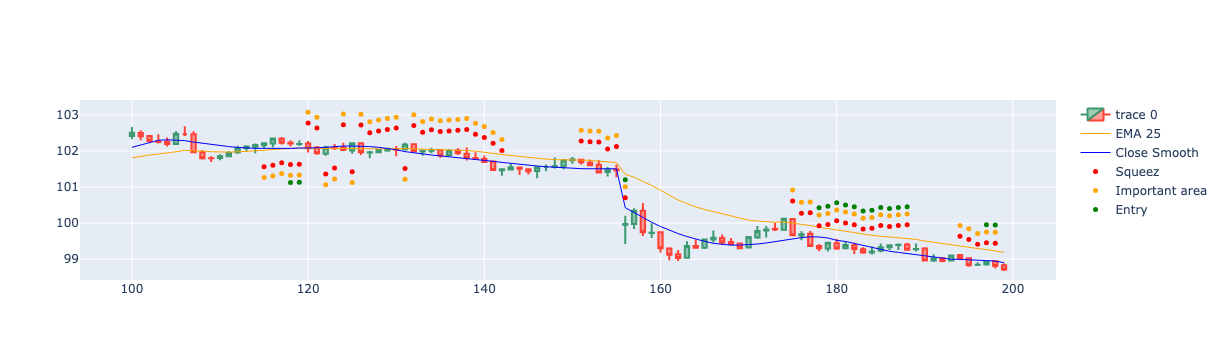

In [10]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = df[100:200]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['open_5min'],
            high=dfpl['high_5min'],
            low=dfpl['low_5min'],
            close=dfpl['close_5min']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema25_5min'],
            line=dict(color='orange', width=1), 
            name="EMA 25"),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['close5min_smooth'],
            line=dict(color='blue', width=1), 
            name="Close Smooth")
    ]
)

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()